# Validación de los datos contra el diccionario

Contrasta `data/` del bucket con `kickoff_docs/LATAM_Bank_Complete_Data_Dictionary.pdf`, transcrito en [`data_dictionary.py`](../data_dictionary.py). Los chequeos están en [`quality.py`](../quality.py) y la lectura desde S3 en [`bank_data.py`](../bank_data.py).

La primera ejecución baja unos 5 GB y los guarda como Parquet en `data/cache/` (≈10 min). Las siguientes tardan segundos. Para refrescar desde S3: `load_table(t, refresh=True)`.

## Hallazgos (ejecución del 2026-09-25)

| Tema | Diccionario | Datos reales |
|---|---|---|
| Esquema | 13 tablas | Las 13 coinciden columna por columna y en orden, en los 7.671 archivos. **Sin evolución de esquema** en `data/` |
| Filas, dimensiones | customers 150k, products 400k… | Exactas |
| Filas, hechos | transactions 5M, interactions 800k, … | **11–16 % menos** en todas, salvo `digital_events`, con **15,6M (+56 %)** |
| `daily_exchange_rates` | 3.000 | 13.164 (= 1.097 días × 12 pares de monedas) |
| Duplicados (~2 %) | Sí | **0**: ni por PK, ni filas idénticas, ni filas idénticas salvo el ID |
| NOT NULL | — | Solo `call_transcripts.duration_seconds`: 24.029 nulos (14 %) |
| Valores categóricos | En inglés | Varias columnas **en español**: `product_type` (y aparece `Seguro`, no documentado), `reason_category` (y `Retención`), `detected_sentiment` (y `Muy Positivo`), `geographic_zone`, `document_type=Pasaporte`, `country=México` con tilde, `channel=Web` en interactions |
| FKs | Íntegras, "pocos huérfanos" | **`customers.registration_branch_id` y `service_agents.assigned_branch_id` no apuntan a `branches`** (≈100 % huérfanos: son IDs aleatorios, uno distinto por cliente). El resto de las FKs: 0 huérfanos |
| Llegadas tardías | Sí | Ningún evento cae en una partición posterior a su fecha. `process_date` corta a las **06:00**: los eventos de 00:00–05:59 van a la partición del día anterior (por eso ~25 % de las transacciones tienen fecha "del día siguiente"). Las encuestas llegan hasta 2 días después de su partición |
| Escalas de encuestas | CSAT 1–5, NPS 0–10 | CSAT y CES solo usan **1–4**, y NPS solo **2–7**: **no hay promotores**. Todos los NPS son Detractor o Passive; `nps_category` es nulo en ~5 % |


## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "bank_data.py").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

import quality as q
from bank_data import headers, load_table
from data_dictionary import FOREIGN_KEYS, TABLES

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.width", 200)

In [2]:
# digital_events tiene ~15M filas: se cargan solo las columnas usadas en los chequeos
DE_COLS = ["event_id", "event_date", "process_date", "customer_id", "session_id", "event_type",
           "event_category", "channel", "platform", "product_id", "is_mobile", "_partition_date", "_source_key"]

T = {t: load_table(t, columns=DE_COLS if t == "digital_events" else None) for t in TABLES}
{t: f"{len(df):,}" for t, df in T.items()}

{'customers': '150,000',
 'products': '400,000',
 'branches': '350',
 'service_agents': '1,200',
 'marketing_campaigns': '200',
 'transactions': '4,425,008',
 'call_center_interactions': '686,296',
 'call_transcripts': '171,321',
 'satisfaction_surveys': '212,759',
 'digital_events': '15,620,994',
 'complaints': '67,095',
 'campaign_sends': '1,746,801',
 'daily_exchange_rates': '13,164'}

## 1. Esquema: columnas de cada archivo vs diccionario

Lee solo el header de cada CSV (≈1–2 min para los ~7.600 archivos). Más de una variante por tabla indicaría evolución de esquema.

In [3]:
rows = []
for t, spec in TABLES.items():
    h = headers(t)
    for cols, g in h.groupby("columns"):
        doc = spec["columns"]
        rows.append({
            "table": t, "files": len(g),
            "from": g["partition_date"].min(), "to": g["partition_date"].max(),
            "missing_vs_doc": [c for c in doc if c not in cols],
            "extra_vs_doc": [c for c in cols if c not in doc],
            "same_order": [c for c in cols if c in doc] == [c for c in doc if c in cols],
        })
schema = pd.DataFrame(rows)
schema["variants"] = schema.groupby("table")["table"].transform("size")
schema

,table,files,from,to,missing_vs_doc,extra_vs_doc,same_order,variants
0,customers,1,NaT,NaT,[],[],True,1
1,products,1,NaT,NaT,[],[],True,1
2,branches,1,NaT,NaT,[],[],True,1
3,service_agents,1,NaT,NaT,[],[],True,1
4,marketing_campaigns,1,NaT,NaT,[],[],True,1
5,transactions,1097,2023-06-17,2026-06-17,[],[],True,1
6,call_center_interactions,1097,2023-06-17,2026-06-17,[],[],True,1
7,call_transcripts,1097,2023-06-17,2026-06-17,[],[],True,1
8,satisfaction_surveys,1097,2023-06-17,2026-06-17,[],[],True,1
9,digital_events,1097,2023-06-17,2026-06-17,[],[],True,1


## 2. Resumen por tabla

- `rows_vs_doc_%`: diferencia contra el conteo documentado.
- `exact_dup_rows`: filas idénticas en todas las columnas.
- `pk_dup_keys`: claves primarias repetidas.
- `pk_conflicts`: misma PK con contenido distinto.
- `null_%_nullable_cols`: promedio de nulos en las columnas no obligatorias; muchas son nulas por diseño, como `credit_limit` en productos que no son de crédito.

In [4]:
summary = pd.DataFrame([q.summary(T[t], t, TABLES[t]) for t in TABLES]).set_index("table")
summary

,rows,rows_doc,rows_vs_doc_%,exact_dup_rows,exact_dup_%,pk_dup_keys,pk_conflicts,not_null_violations,null_%_nullable_cols
table,,,,,,,,,
customers,150000,150000,0.00,0,0.0,0,0,0,13.75
products,400000,400000,0.00,0,0.0,0,0,0,47.53
branches,350,350,0.00,0,0.0,0,0,0,0.00
service_agents,1200,1200,0.00,0,0.0,0,0,0,19.28
marketing_campaigns,200,200,0.00,0,0.0,0,0,0,24.67
transactions,4425008,5000000,-11.50,0,0.0,0,0,0,53.66
call_center_interactions,686296,800000,-14.21,0,0.0,0,0,0,18.19
call_transcripts,171321,200000,-14.34,0,0.0,0,0,24029,8.00
satisfaction_surveys,212759,250000,-14.90,0,0.0,0,0,0,43.32


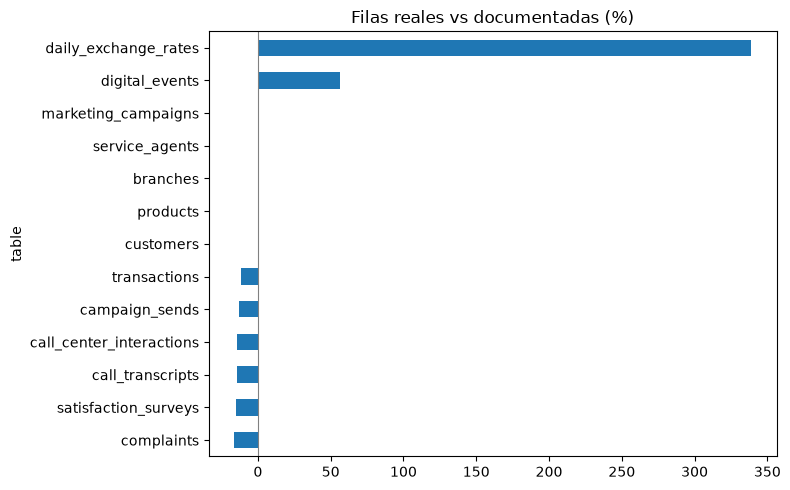

In [5]:
ax = summary["rows_vs_doc_%"].sort_values().plot.barh(figsize=(8, 5), title="Filas reales vs documentadas (%)")
ax.axvline(0, color="grey", lw=0.8)
plt.tight_layout()

In [6]:
# Duplicados "de negocio": filas idénticas salvo el ID (p. ej. la misma transacción reenviada con otro ID)
dup_biz = {}
for t, spec in TABLES.items():
    if spec["kind"] != "fact" or t == "digital_events":
        continue
    cols = [c for c in q.data_cols(T[t]) if c not in spec["pk"]]
    dup_biz[t] = int(T[t].duplicated(cols).sum())
pd.Series(dup_biz, name="rows_identical_except_pk")

transactions                0
call_center_interactions    0
call_transcripts            0
satisfaction_surveys        0
complaints                  0
campaign_sends              0
Name: rows_identical_except_pk, dtype: int64

## 3. Nulos en columnas NOT NULL

In [7]:
pd.concat({t: q.not_null_violations(T[t], TABLES[t]) for t in TABLES}, names=["table", "column"]).rename("nulls").to_frame()

,,nulls
table,column,
call_transcripts,duration_seconds,24029


In [8]:
# Tasa de nulos por columna de una tabla
TABLE = "call_transcripts"
q.null_rates(T[TABLE]).to_frame("null_%")

,null_%
detected_accent,36.82
duration_seconds,14.03
mentioned_entities,10.02
accent_confidence,10.01
detected_keywords,5.13
audio_quality,5.04
detected_intents,4.94
process_date,0.00
customer_id,0.00
agent_id,0.00


## 4. Valores categóricos fuera de lo documentado

In [9]:
enum_issues = pd.concat({t: q.enum_violations(T[t], TABLES[t]) for t in TABLES}, names=["table", "i"])
enum_issues.droplevel("i") if len(enum_issues) else "sin problemas"

,column,documented,unexpected_values,unexpected_%
table,,,,
customers,document_type,"[DNI, CURP, CC, CE, Passport]",{'Pasaporte': 15062},10.04
customers,country,"[Mexico, Colombia, Argentina]",{'México': 74907},49.94
products,product_type,"[Checking Account, Savings Account, Credit Card, Debit Card, Personal Loan, Mortgage, Investment]","{'Cuenta Ahorro': 120203, 'Tarjeta Crédito': 100102, 'Cuenta Corriente': 99979, 'Tarjeta Débito': 39938, 'Préstamo Personal': 19960, 'Préstamo Hip...",100.00
branches,geographic_zone,"[Urban, Suburban, Rural]",{'Urbana': 350},100.00
call_center_interactions,channel,"[Phone, Web Chat, WhatsApp, Email, App]",{'Web': 3395},0.49
call_center_interactions,reason_category,"[Transactional, Product, Technical, Commercial, Complaint]","{'Transaccional': 240056, 'Producto': 150863, 'Queja': 117021, 'Técnico': 102899, 'Comercial': 54879, 'Retención': 20578}",100.00
call_center_interactions,detected_sentiment,"[Positive, Neutral, Negative, Very Negative]","{'Negativo': 94322, 'Positivo': 75562, 'Muy Negativo': 37727, 'Muy Positivo': 18973}",33.02


In [10]:
# Valores reales de una columna, para comparar con el diccionario
T["products"]["product_type"].value_counts()

product_type
Cuenta Ahorro           120203
Tarjeta Crédito         100102
Cuenta Corriente         99979
Tarjeta Débito           39938
Préstamo Personal        19960
Préstamo Hipotecario     11910
Inversión                 5859
Seguro                    2049
Name: count, dtype: int64

## 5. Rangos numéricos documentados

In [11]:
pd.concat({t: q.range_violations(T[t], TABLES[t]) for t in TABLES if TABLES[t].get("ranges")}, names=["table", "i"]).droplevel("i")

,column,range,min,max,violations,non_numeric
table,,,,,,
customers,credit_score,"(300, 850)",422.00,850.00,0,0
service_agents,avg_csat,"(1, 5)",3.50,5.00,0,0
transactions,fraud_score,"(0, 100)",0.00,99.99,0,0
call_center_interactions,sentiment_score,"(-1, 1)",-1.00,1.00,0,0
call_transcripts,accent_confidence,"(0, 1)",0.75,0.99,0,0
satisfaction_surveys,main_score,"(0, 10)",1.00,7.00,0,0
satisfaction_surveys,question_1_response,"(1, 5)",1.00,5.00,0,0
satisfaction_surveys,question_2_response,"(1, 5)",1.00,5.00,0,0
satisfaction_surveys,question_3_response,"(1, 5)",1.00,5.00,0,0


In [12]:
# Escalas reales de las encuestas: CSAT/CES nunca llegan a 5 y NPS nunca pasa de 7 (sin promotores)
s = T["satisfaction_surveys"]
nps = s[s["survey_type"] == "NPS"]
display(s.groupby("survey_type")["main_score"].agg(lambda x: sorted(pd.to_numeric(x).unique())))
pd.crosstab(pd.to_numeric(nps["main_score"]), nps["nps_category"].fillna("<null>"))

survey_type
CES           [1, 2, 3, 4]
CSAT          [1, 2, 3, 4]
NPS     [2, 3, 4, 5, 6, 7]
Name: main_score, dtype: object

nps_category,<null>,Detractor,Passive
main_score,,,
2,237,4621,0
3,270,4630,0
4,268,4608,0
5,824,15651,0
6,832,15497,0
7,843,0,15387


## 6. Fechas de evento vs partición (llegadas tardías)

`lag_days` = fecha de la partición − fecha del evento.
- `> 0`: el evento llegó tarde, en una partición posterior.
- `< 0`: el evento ocurre después de su partición.

In [13]:
lag = {}
for t, spec in TABLES.items():
    if spec["kind"] != "fact":
        continue
    a = q.arrival_lag(T[t], spec)
    row = {"process_date≠partition": int(a["process_date_mismatch"].sum())}
    if "lag_days" in a:
        row.update(a["lag_days"].value_counts().sort_index().rename(lambda d: f"lag {d:+d}d").to_dict())
    lag[t] = row
pd.DataFrame(lag).T.fillna(0).astype(int)

,process_date≠partition,lag -1d,lag +0d,lag -2d
transactions,0,1106307,3318701,0
call_center_interactions,0,228318,457978,0
call_transcripts,0,0,0,0
satisfaction_surveys,0,156851,43667,12241
digital_events,0,3930816,11690178,0
complaints,0,22585,44510,0
campaign_sends,0,436429,1310372,0


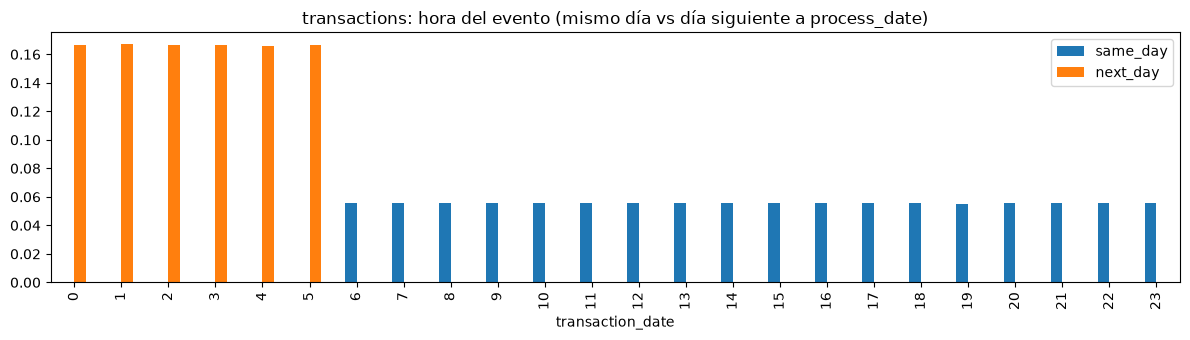

In [14]:
# Los eventos "del día siguiente" son todos de 00:00–05:59: process_date corta a las 06:00
tx = T["transactions"]
ts = pd.to_datetime(tx["transaction_date"])
next_day = ts.dt.normalize() > tx["_partition_date"]
pd.DataFrame({"same_day": ts[~next_day].dt.hour.value_counts(normalize=True),
              "next_day": ts[next_day].dt.hour.value_counts(normalize=True)}).sort_index().plot.bar(
    figsize=(12, 3.5), title="transactions: hora del evento (mismo día vs día siguiente a process_date)")
plt.tight_layout()

## 7. Integridad referencial (FKs)

In [15]:
fk = q.fk_orphans(T, FOREIGN_KEYS)
fk

,fk,non_null,orphans,orphan_%,examples
8,customers.registration_branch_id → branches.branch_id,150000,149995,99.997,"[SUC-7R3DCC91, SUC-7ZI313MS, SUC-48CL872M]"
10,service_agents.assigned_branch_id → branches.branch_id,833,831,99.760,"[SUC-L138LKPP, SUC-D79XNL6Q, SUC-Z3ECV86G]"
0,products.customer_id → customers.customer_id,400000,0,0.000,[]
13,call_center_interactions.agent_id → service_agents.agent_id,686296,0,0.000,[]
21,call_transcripts.interaction_id → call_center_interactions.interaction_id,171321,0,0.000,[]
20,campaign_sends.campaign_id → marketing_campaigns.campaign_id,1746801,0,0.000,[]
19,complaints.affected_product_id → products.product_id,44570,0,0.000,[]
18,digital_events.product_id → products.product_id,1440338,0,0.000,[]
17,transactions.product_id → products.product_id,4425008,0,0.000,[]
16,complaints.assigned_agent_id → service_agents.agent_id,43980,0,0.000,[]


In [16]:
# Detalle: registration_branch_id parece un ID aleatorio por cliente, no una sucursal
cu, br = T["customers"], T["branches"]
pd.Series({
    "clientes": len(cu),
    "registration_branch_id distintos": cu["registration_branch_id"].nunique(),
    "sucursales en branches": len(br),
    "coinciden con branches.branch_id": int(cu["registration_branch_id"].isin(br["branch_id"]).sum()),
    "coinciden con branches.branch_code": int(cu["registration_branch_id"].isin(br["branch_code"]).sum()),
})

clientes                              150000
registration_branch_id distintos      150000
sucursales en branches                   350
coinciden con branches.branch_id           5
coinciden con branches.branch_code         0
dtype: int64